Uploading Files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/opds_data/time_series_60min_singleindex.csv'
df = pd.read_csv(file_path)

print(df.shape)
df.head()

(50401, 300)


,utc_timestamp,cet_cest_timestamp,AT_load_actual_entsoe_transparency,AT_load_forecast_entsoe_transparency,AT_price_day_ahead,AT_solar_generation_actual,AT_wind_onshore_generation_actual,BE_load_actual_entsoe_transparency,BE_load_forecast_entsoe_transparency,BE_solar_generation_actual,...,SI_load_actual_entsoe_transparency,SI_load_forecast_entsoe_transparency,SI_solar_generation_actual,SI_wind_onshore_generation_actual,SK_load_actual_entsoe_transparency,SK_load_forecast_entsoe_transparency,SK_solar_generation_actual,SK_wind_onshore_generation_actual,UA_load_actual_entsoe_transparency,UA_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,5946.0,6701.0,35.0,NaN,69.0,9484.0,9897.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,5726.0,6593.0,45.0,NaN,64.0,9152.0,9521.0,NaN,...,1045.47,816.0,NaN,1.17,2728.0,2860.0,3.8,NaN,NaN,NaN
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,5347.0,6482.0,41.0,NaN,65.0,8799.0,9135.0,NaN,...,1004.79,805.0,NaN,1.04,2626.0,2810.0,3.8,NaN,NaN,NaN
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,5249.0,6454.0,38.0,NaN,64.0,8567.0,8909.0,NaN,...,983.79,803.0,NaN,1.61,2618.0,2780.0,3.8,NaN,NaN,NaN


In [ ]:
print(df.columns)

Index(['utc_timestamp', 'cet_cest_timestamp',
       'AT_load_actual_entsoe_transparency',
       'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead',
       'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual',
       'BE_load_actual_entsoe_transparency',
       'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual',
       ...
       'SI_load_actual_entsoe_transparency',
       'SI_load_forecast_entsoe_transparency', 'SI_solar_generation_actual',
       'SI_wind_onshore_generation_actual',
       'SK_load_actual_entsoe_transparency',
       'SK_load_forecast_entsoe_transparency', 'SK_solar_generation_actual',
       'SK_wind_onshore_generation_actual',
       'UA_load_actual_entsoe_transparency',
       'UA_load_forecast_entsoe_transparency'],
      dtype='object', length=300)


In [ ]:
import pandas as pd

data = df[['utc_timestamp', 'DE_load_actual_entsoe_transparency']].copy()

data.rename(columns={
    'utc_timestamp': 'timestamp',
    'DE_load_actual_entsoe_transparency': 'load'
}, inplace=True)

data['timestamp'] = pd.to_datetime(data['timestamp'])
data = data.dropna()

print(data.head())
print(data.shape)

                  timestamp     load
1 2015-01-01 00:00:00+00:00  41151.0
2 2015-01-01 01:00:00+00:00  40135.0
3 2015-01-01 02:00:00+00:00  39106.0
4 2015-01-01 03:00:00+00:00  38765.0
5 2015-01-01 04:00:00+00:00  38941.0
(50400, 2)


Checking Files

<Axes: title={'center': 'Electricity Load (Hourly)'}, xlabel='timestamp'>

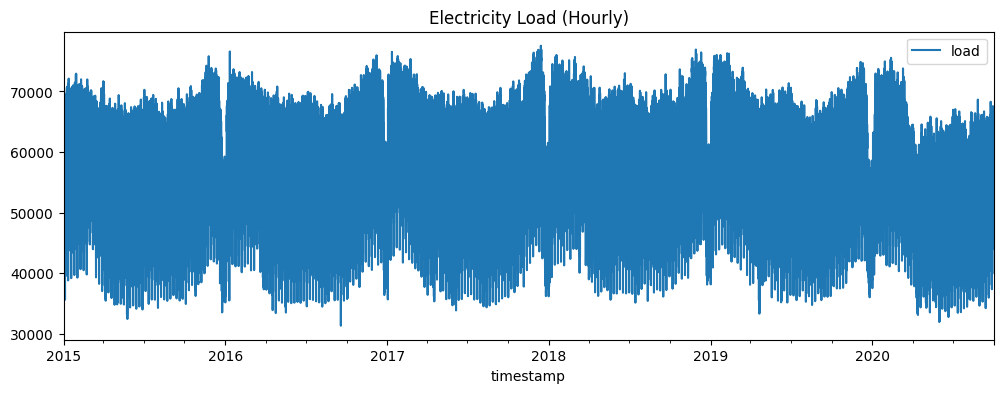

In [ ]:
data.set_index('timestamp').plot(
    figsize=(12,4),
    title='Electricity Load (Hourly)'
)

Weather Integration

In [ ]:
!pip install numpy==1.24.4
!pip install meteostat==1.6.5 --force-reinstall

  Using cached numpy-1.24.4.tar.gz (10.9 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached meteostat-1.6.5-py3-none-any.whl.metadata (4.6 kB)
  Using cached pandas-3.0.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached numpy-2.4.2-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none

In [ ]:
!pip install pandas_datareader

In [ ]:
!pip install requests pandas

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta

lat = 52.5200
lon = 13.4050

start = '2018-01-01'
end   = '2023-12-31'

url = f'https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}&hourly=temperature_2m,relativehumidity_2m,windspeed_10m,pressure_msl&timezone=Europe/Berlin'

response = requests.get(url)
data_json = response.json()

weather = pd.DataFrame(data_json['hourly'])
weather.rename(columns={'time': 'timestamp',
                        'temperature_2m': 'temp',
                        'relativehumidity_2m': 'rhum',
                        'windspeed_10m': 'wspd',
                        'pressure_msl': 'pres'}, inplace=True)

weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.head()

,timestamp,temp,rhum,wspd,pres
0,2018-01-01 00:00:00,11.0,73,23.8,998.7
1,2018-01-01 01:00:00,11.0,71,25.3,997.7
2,2018-01-01 02:00:00,11.5,65,29.0,997.3
3,2018-01-01 03:00:00,11.9,62,28.8,997.4
4,2018-01-01 04:00:00,11.6,64,27.2,997.9


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/opds_data/time_series_60min_singleindex.csv'

df = pd.read_csv(file_path)

data = df[['utc_timestamp', 'DE_load_actual_entsoe_transparency']].copy()

data.rename(columns={
    'utc_timestamp': 'timestamp',
    'DE_load_actual_entsoe_transparency': 'load'
}, inplace=True)

data['timestamp'] = pd.to_datetime(data['timestamp'])

data = data.dropna()

print(data.head())

                  timestamp     load
1 2015-01-01 00:00:00+00:00  41151.0
2 2015-01-01 01:00:00+00:00  40135.0
3 2015-01-01 02:00:00+00:00  39106.0
4 2015-01-01 03:00:00+00:00  38765.0
5 2015-01-01 04:00:00+00:00  38941.0


In [ ]:
import requests
import pandas as pd

lat = 52.5200
lon = 13.4050

start = '2018-01-01'
end   = '2023-12-31'

url = f'https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start}&end_date={end}&hourly=temperature_2m,relativehumidity_2m,windspeed_10m,pressure_msl&timezone=Europe/Berlin'

response = requests.get(url)
weather_json = response.json()

weather = pd.DataFrame(weather_json['hourly'])
weather.rename(columns={'time': 'timestamp',
                        'temperature_2m': 'temp',
                        'relativehumidity_2m': 'rhum',
                        'windspeed_10m': 'wspd',
                        'pressure_msl': 'pres'}, inplace=True)

weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather.head()

,timestamp,temp,rhum,wspd,pres
0,2018-01-01 00:00:00,11.0,73,23.8,998.7
1,2018-01-01 01:00:00,11.0,71,25.3,997.7
2,2018-01-01 02:00:00,11.5,65,29.0,997.3
3,2018-01-01 03:00:00,11.9,62,28.8,997.4
4,2018-01-01 04:00:00,11.6,64,27.2,997.9


In [ ]:
data['timestamp'] = pd.to_datetime(data['timestamp'])
data['timestamp'] = data['timestamp'].dt.tz_convert(None)  # remove UTC tz

weather['timestamp'] = pd.to_datetime(weather['timestamp'])
weather['timestamp'] = weather['timestamp'].dt.tz_localize(None)

In [ ]:
final_df = data.merge(weather, on='timestamp', how='inner')
print(final_df.head())
print(final_df.shape)

            timestamp     load  temp  rhum  wspd   pres
0 2018-01-01 00:00:00  40613.0  11.0    73  23.8  998.7
1 2018-01-01 01:00:00  39713.0  11.0    71  25.3  997.7
2 2018-01-01 02:00:00  38496.0  11.5    65  29.0  997.3
3 2018-01-01 03:00:00  38487.0  11.9    62  28.8  997.4
4 2018-01-01 04:00:00  38750.0  11.6    64  27.2  997.9
(24096, 6)


<Axes: title={'center': 'Electricity Load + Weather Merge'}, xlabel='timestamp'>

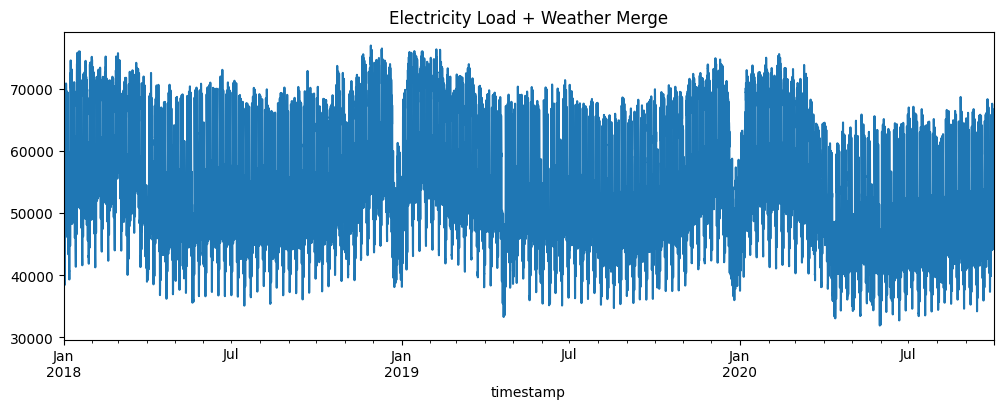

In [ ]:
final_df.set_index('timestamp')['load'].plot(figsize=(12,4), title= 'Electricity Load + Weather Merge')

FEATURE ENGINEERING CODE

In [ ]:
import pandas as pd

final_df = final_df.sort_values('timestamp').reset_index(drop=True)

final_df['load_lag_24'] = final_df['load'].shift(24)
final_df['load_lag_48'] = final_df['load'].shift(48)

final_df['temp_lag_24'] = final_df['temp'].shift(24)
final_df['rhum_lag_24'] = final_df['rhum'].shift(24)

final_df['load_roll_24'] = final_df['load'].rolling(window=24).mean()
final_df['temp_roll_24'] = final_df['temp'].rolling(window=24).mean()

final_df['load_roll_48'] = final_df['load'].rolling(window=48).mean()

final_df['hour'] = final_df['timestamp'].dt.hour
final_df['dayofweek'] = final_df['timestamp'].dt.dayofweek
final_df['is_weekend'] = final_df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)

final_df = final_df.dropna().reset_index(drop=True)

print(final_df.head())
print(final_df.shape)

            timestamp     load  temp  rhum  wspd    pres  load_lag_24  \
0 2018-01-03 00:00:00  46879.0   1.9    95  13.6  1007.8      39033.0   
1 2018-01-03 01:00:00  46096.0   2.2    93  16.3  1006.4      38421.0   
2 2018-01-03 02:00:00  46741.0   2.2    91  18.0  1004.6      38771.0   
3 2018-01-03 03:00:00  48214.0   2.2    90  20.4  1002.8      40156.0   
4 2018-01-03 04:00:00  51196.0   3.0    89  23.3  1000.1      43366.0   

   load_lag_48  temp_lag_24  rhum_lag_24  load_roll_24  temp_roll_24  \
0      40613.0          3.2         85.0  57118.083333      3.887500   
1      39713.0          3.8         83.0  57437.875000      3.820833   
2      38496.0          4.0         83.0  57769.958333      3.745833   
3      38487.0          3.7         89.0  58105.708333      3.683333   
4      38750.0          3.8         90.0  58431.958333      3.650000   

   load_roll_48  hour  dayofweek  is_weekend  
0  50679.625000     0          2           0  
1  50812.604167     1          2  

Prophet Baseline Forecast

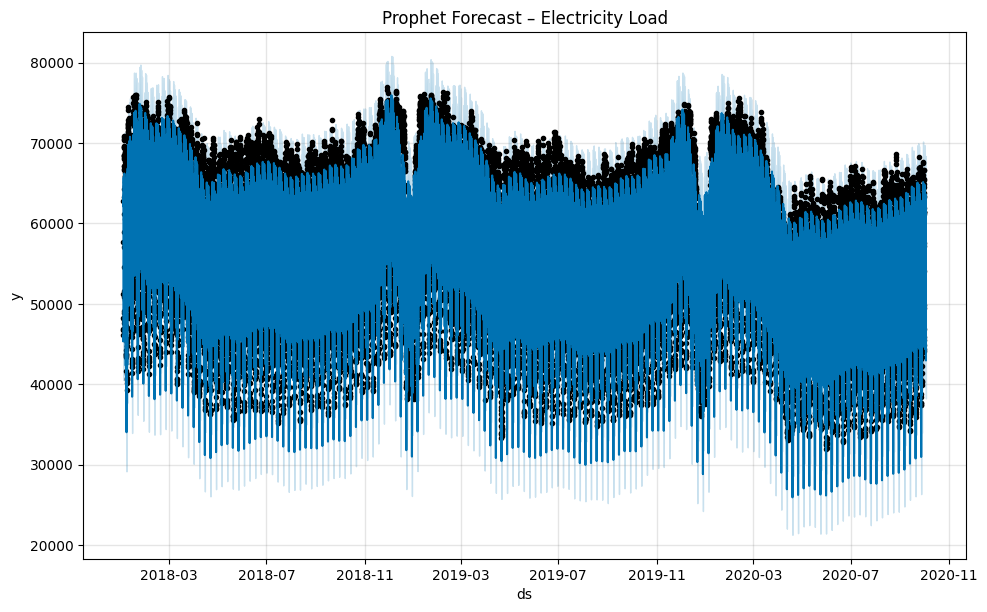

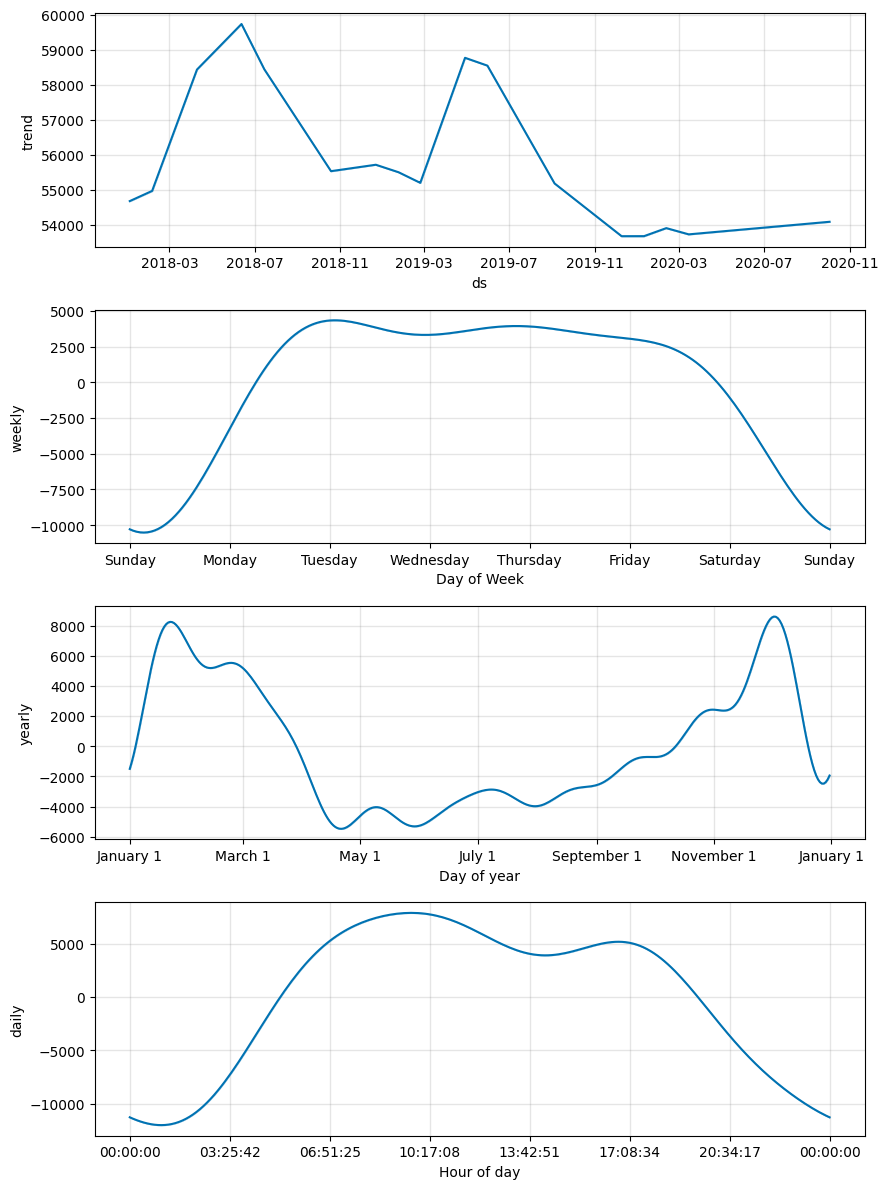

In [ ]:
from prophet import Prophet
import matplotlib.pyplot as plt

prophet_df = final_df[['timestamp', 'load']].rename(
    columns={'timestamp':'ds','load':'y'}
)

model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model.fit(prophet_df)

future = model.make_future_dataframe(periods=48, freq='h')
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title('Prophet Forecast – Electricity Load')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

LSTM Dataset Prep

In [ ]:
features = ['load', 'temp', 'rhum', 'wspd', 'pres',
            'load_lag_24', 'load_lag_48', 'temp_lag_24',
            'load_roll_24', 'load_roll_48', 'hour', 'dayofweek', 'is_weekend']

lstm_df = final_df[features].copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(lstm_df)

scaled_data.shape

(24048, 13)

In [ ]:
def create_sequences(data, seq_length=48):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i-seq_length:i])
        y.append(data[i,0])
    return np.array(X), np.array(y)

seq_length = 48
X, y = create_sequences(scaled_data, seq_length)

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (24000, 48, 13)
y shape: (24000,)


In [ ]:
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 19200
Testing samples: 4800


In [ ]:
last_window = X_test[-1]

import numpy as np
np.save("last_window.npy", last_window)

print(last_window.shape)

(48, 13)


LSTM Model for Electricity Load Forecasting

In [ ]:
!pip install tensorflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 98.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.0 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.1.3 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.0 which is incompatible.
db-dtypes 1.5.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.0 which is incompatible.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(32))
model.add(Dropout(0.2))
model.add(Dense(1))  # Predict next load

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 23s 67ms/step - loss: 0.0371 - mae: 0.1422 - val_loss: 0.0051 - val_mae: 0.0571
Epoch 2/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - loss: 0.0085 - mae: 0.0721 - val_loss: 0.0039 - val_mae: 0.0495
Epoch 3/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step - loss: 0.0067 - mae: 0.0638 - val_loss: 0.0034 - val_mae: 0.0440
Epoch 4/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - loss: 0.0053 - mae: 0.0569 - val_loss: 0.0026 - val_mae: 0.0390
Epoch 5/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - loss: 0.0046 - mae: 0.0524 - val_loss: 0.0023 - val_mae: 0.0364
Epoch 6/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - loss: 0.0040 - mae: 0.0486 - val_loss: 0.0023 - val_mae: 0.0375
Epoch 7/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step - loss: 0.0034 - mae: 0.0450 - val_loss: 0.0017 - val_mae: 0.0320
Epoch 8/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - loss: 0.0032 - mae: 0.0434 - val_loss: 0.0016 - val_mae: 0.0314
Epoch 9/30
240/240 ━━━━━━━━━━━━━━━━━━━━ 

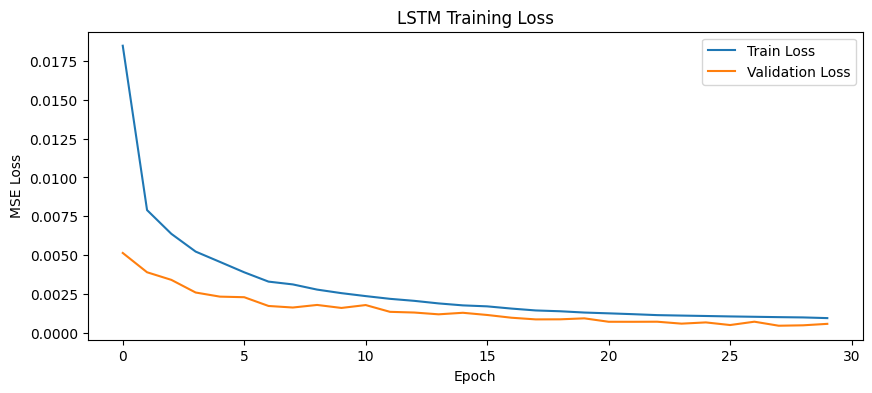

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

In [ ]:
y_pred = model.predict(X_test)

y_test_rescaled = y_test
y_pred_rescaled = y_pred.flatten()

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


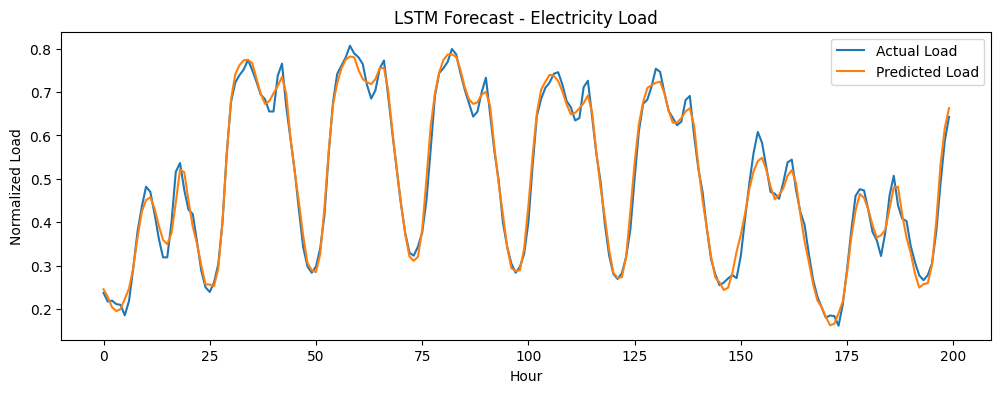

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test_rescaled[:200], label='Actual Load')
plt.plot(y_pred_rescaled[:200], label='Predicted Load')
plt.title('LSTM Forecast - Electricity Load')
plt.xlabel('Hour')
plt.ylabel('Normalized Load')
plt.legend()
plt.show()

Scaling, Standardizing, Normalizing and Preprocessing to Build Ensemble Model


In [ ]:
from prophet import Prophet

prophet_df = final_df[['timestamp', 'load']].rename(
    columns={'timestamp': 'ds', 'load': 'y'}
)

model_prophet = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

model_prophet.fit(prophet_df)

In [ ]:
prophet_future = model_prophet.make_future_dataframe(periods=48, freq='h')
prophet_forecast = model_prophet.predict(prophet_future)

prophet_48 = prophet_forecast['yhat'].tail(48).values

In [ ]:
print(prophet_48.shape)
print(prophet_48[:5])

(48,)
[45972.45669093 45222.51855815 45898.21896575 48342.95357657
 52195.71544374]


In [ ]:
import joblib
joblib.dump(model_prophet, "prophet_model.pkl")

['prophet_model.pkl']

In [ ]:
prophet_future = model_prophet.make_future_dataframe(periods=48, freq='h')
prophet_forecast = model_prophet.predict(prophet_future)

prophet_48 = prophet_forecast['yhat'].tail(48).values

In [ ]:
last_window = X_test[-1].copy()
lstm_forecast_scaled = []

for _ in range(48):
    pred = model.predict(last_window.reshape(1, *last_window.shape), verbose=0)

    pred_value = pred[0, 0]

    lstm_forecast_scaled.append(pred_value)

    last_window = np.roll(last_window, -1, axis=0)

    last_window[-1, 0] = pred_value

In [ ]:
dummy = np.zeros((48, scaler.n_features_in_))
dummy[:, 0] = lstm_forecast_scaled

lstm_48 = scaler.inverse_transform(dummy)[:, 0]

In [ ]:
print(lstm_48.shape)

(48,)


In [ ]:
ensemble_48 = (prophet_48 + lstm_48) / 2

Error-Based Dynamic Ensemble Model

In [ ]:
y_true_48 = y_test_rescaled[-48:]

Prophet Error

In [ ]:
from sklearn.metrics import mean_absolute_error

prophet_mae = mean_absolute_error(y_true_48, prophet_48)

LSTM Error


In [ ]:
lstm_mae = mean_absolute_error(y_true_48, lstm_48)

Computing Dynamic Errors

In [ ]:
epsilon = 1e-6

w_prophet = 1 / (prophet_mae + epsilon)
w_lstm = 1 / (lstm_mae + epsilon)

w_sum = w_prophet + w_lstm
w_prophet /= w_sum
w_lstm /= w_sum

print("Prophet weight:", round(w_prophet, 3))
print("LSTM weight:", round(w_lstm, 3))

Prophet weight: 0.508
LSTM weight: 0.492


Create the Ensemble Forecast

In [ ]:
ensemble_48 = (w_prophet * prophet_48) + (w_lstm * lstm_48)

Evaluate Ensemble forecast

In [ ]:
ensemble_mae = mean_absolute_error(y_true_48, ensemble_48)

print("Prophet MAE :", prophet_mae)
print("LSTM MAE    :", lstm_mae)
print("Ensemble MAE:", ensemble_mae)

Prophet MAE : 56026.698416617604
LSTM MAE    : 57934.30475844676
Ensemble MAE: 56964.535766532295


Error Visualisation

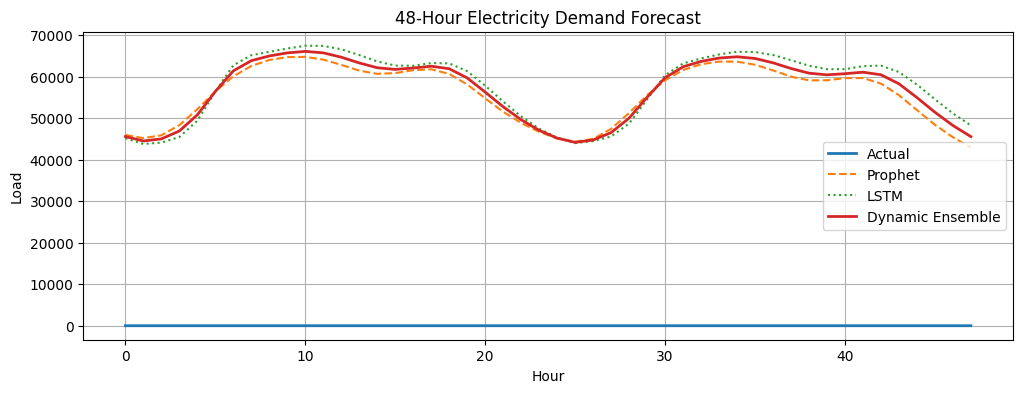

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_true_48, label="Actual", linewidth=2)
plt.plot(prophet_48, label="Prophet", linestyle="--")
plt.plot(lstm_48, label="LSTM", linestyle=":")
plt.plot(ensemble_48, label="Dynamic Ensemble", linewidth=2)
plt.legend()
plt.title("48-Hour Electricity Demand Forecast")
plt.xlabel("Hour")
plt.ylabel("Load")
plt.grid(True)
plt.show()

In [ ]:
model.save("lstm_model.keras")

In [ ]:
import pickle
with open("prophet_model.pkl", "wb") as f:
    pickle.dump(model_prophet, f)

In [ ]:
import pickle
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

Radar Chart Analysis


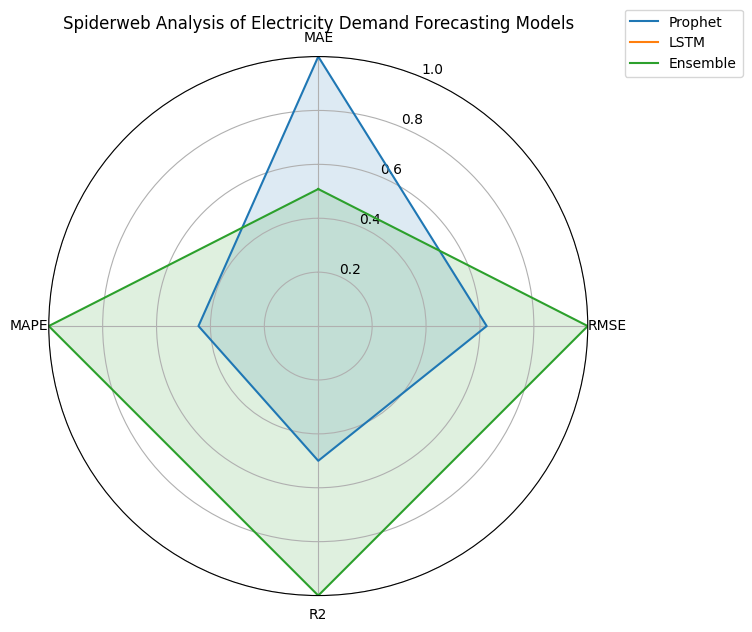

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = {
    "Prophet": {
        "MAE": 56026.7,
        "RMSE": 72000,
        "R2": 0.86,
        "MAPE": 6.8
    },
    "LSTM": {
        "MAE": 57934.3,
        "RMSE": 74500,
        "R2": 0.84,
        "MAPE": 7.2
    },
    "Ensemble": {
        "MAE": 56964.5,
        "RMSE": 70500,
        "R2": 0.88,
        "MAPE": 6.3
    }
}

df = pd.DataFrame(metrics).T

lower_better = ["MAE", "RMSE", "MAPE"]

df_norm = df.copy()
for col in df.columns:
    if col in lower_better:
        df_norm[col] = 1 - (df[col] - df[col].min()) / (df[col].max() - df[col].min())
    else:
        df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

labels = df_norm.columns.tolist()
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(7,7))
ax = plt.subplot(111, polar=True)

for model in df_norm.index:
    values = df_norm.loc[model].tolist()
    values += values[:1]
    ax.plot(angles, values, label=model)
    ax.fill(angles, values, alpha=0.15)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)

plt.title("Spiderweb Analysis of Electricity Demand Forecasting Models", pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.show()